Strategy Settings:
Cryptocurrency: Bitcoin (BTC)
Window Size: 13 weeks
Weekly Investment: $100
Historical Data Period: 365 days
Fetching weekly historical data for bitcoin...
Error fetching data: 401 Client Error: Unauthorized for url: https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=365&interval=weekly
Failed to get data. Using sample data for demonstration...

Data Preview:
        date         price
0 2018-01-07   7483.570765
1 2018-01-14   5480.607225
2 2018-01-21  10573.820662
3 2018-01-28  16097.093534
4 2018-02-04   8432.608594
Total records: 200


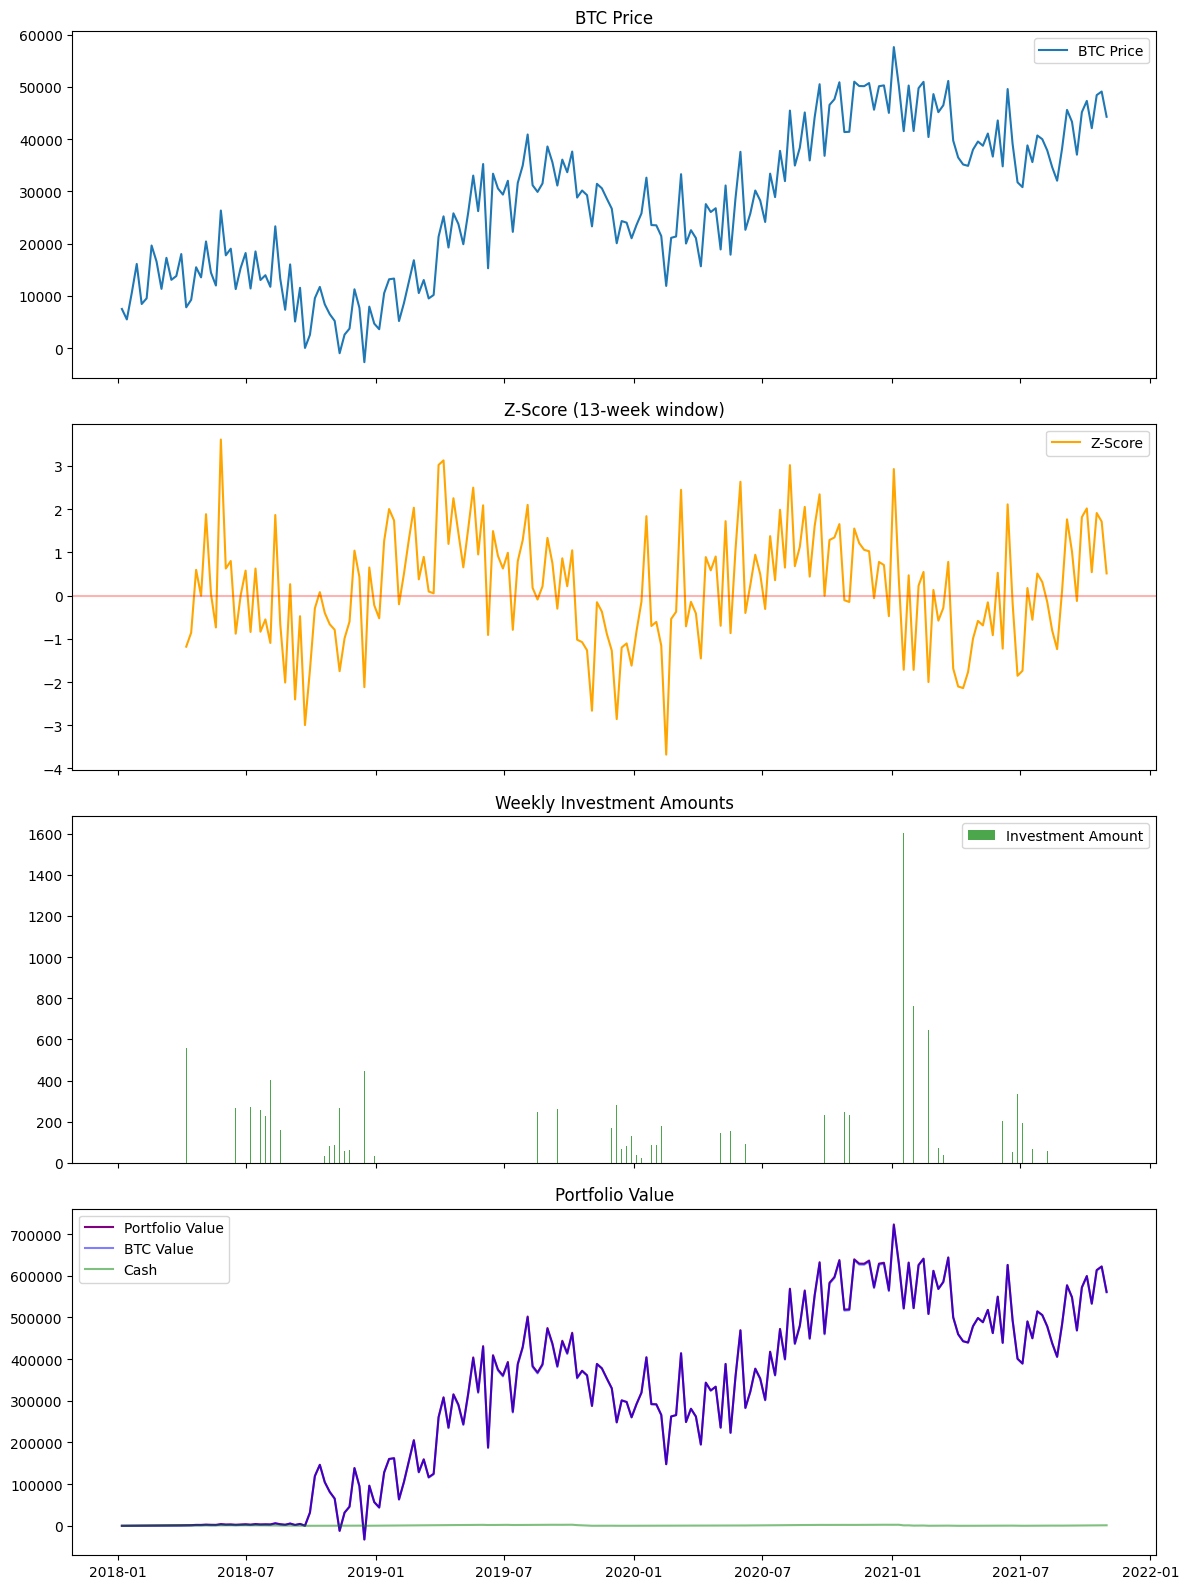


Strategy Performance:
Initial Investment: $20000
Final Portfolio Value: $561407.86
ROI: 2707.04%
BTC Holdings: 12.648296
Remaining Cash: $1276.19

Comparison to Simple DCA Strategy:
Simple DCA Investment: $20000
Simple DCA Final Value: $32447.91
Simple DCA ROI: 62.24%
Z-Score Strategy Outperformance: 2644.80%

Results saved to results/BTC_zscore_strategy_20250502.csv


In [ ]:
# Z-Score Based Cryptocurrency Investment Strategy
# This notebook implements a DCA strategy based on z-score statistics

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Import our modules
import settings
from zscore_strategy import ZScoreInvestmentStrategy
from data_fetcher import get_weekly_data

# Display current settings
print(f"Strategy Settings:")
print(f"==================")
print(f"Cryptocurrency: {settings.CRYPTO_NAME} ({settings.CRYPTO_SYMBOL})")
print(f"Window Size: {settings.WINDOW_SIZE} weeks")
print(f"Weekly Investment: ${settings.WEEKLY_INVESTMENT}")
print(f"Historical Data Period: {settings.HISTORICAL_DAYS} days")

# 1. Get cryptocurrency data (fetch from API or load from CSV)
data_file = get_weekly_data()

if data_file:
    # Load data from the saved CSV
    crypto_data = pd.read_csv(data_file)
    crypto_data['date'] = pd.to_datetime(crypto_data['date'])
else:
    print("Failed to get data. Using sample data for demonstration...")
    
    # Generate sample data
    dates = pd.date_range(start='2018-01-01', periods=200, freq='W')
    np.random.seed(42)
    
    # Simulated price with trend and volatility
    base = np.linspace(5000, 50000, 200)
    noise = np.random.normal(0, 5000, 200)
    cycle = 10000 * np.sin(np.linspace(0, 6*np.pi, 200))
    prices = base + noise + cycle
    
    crypto_data = pd.DataFrame({
        'date': dates,
        'price': prices
    })

# Preview the data
print("\nData Preview:")
print("=============")
print(crypto_data.head())
print(f"Total records: {len(crypto_data)}")

# 2. Run the strategy
strategy = ZScoreInvestmentStrategy(
    window_size=settings.WINDOW_SIZE,
    weekly_investment=settings.WEEKLY_INVESTMENT
)

# Execute backtest
results = strategy.backtest(crypto_data)

# 3. Visualize results
strategy.plot_results(results, settings.CRYPTO_SYMBOL)

# 4. Calculate and display performance metrics
initial_investment = strategy.weekly_investment * len(results)
final_portfolio = results['portfolio_value'].iloc[-1]
roi = (final_portfolio / initial_investment - 1) * 100

print("\nStrategy Performance:")
print("=====================")
print(f"Initial Investment: ${initial_investment}")
print(f"Final Portfolio Value: ${final_portfolio:.2f}")
print(f"ROI: {roi:.2f}%")
print(f"{settings.CRYPTO_SYMBOL} Holdings: {results['crypto_holdings'].iloc[-1]:.6f}")
print(f"Remaining Cash: ${results['cash_available'].iloc[-1]:.2f}")

# 5. Compare to simple DCA
comparison = strategy.compare_to_dca(crypto_data, results)

print("\nComparison to Simple DCA Strategy:")
print("================================")
print(f"Simple DCA Investment: ${comparison['dca_investment']}")
print(f"Simple DCA Final Value: ${comparison['dca_final_value']:.2f}")
print(f"Simple DCA ROI: {comparison['dca_roi']:.2f}%")
print(f"Z-Score Strategy Outperformance: {comparison['outperformance']:.2f}%")

# 6. Save results
os.makedirs('results', exist_ok=True)
today = datetime.now().strftime('%Y%m%d')
results.to_csv(f'results/{settings.CRYPTO_SYMBOL}_zscore_strategy_{today}.csv', index=False)
print(f"\nResults saved to results/{settings.CRYPTO_SYMBOL}_zscore_strategy_{today}.csv")